# Checking the physicality of Samudra simulations

We want to have an automatic way of checking if the predictions of Samudra stay within reasonable physical limits. We have some samples of simulations which predict unphysical stuff, from my first ensemble simulations using a noise level of 5.0. Here, we test methods to determine if a run is broken or not.

In [7]:
from pathlib import Path

import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import cmocean as cm
import cartopy.crs as ccrs
import cartopy.feature as cfeature

landmask_path = Path("../Landmasks/Landmask.zarr")
landmask = xr.open_dataarray(landmask_path)
ocean_mask = ~landmask

/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


In [34]:
unstable_rollout_path = Path("../Rollouts/Unstable-ENS_OM4_thermo-sigma_10.0/predictions.zarr")
unstable_rollout_ds = xr.open_dataset(unstable_rollout_path, chunks=dict(time=1)) * ocean_mask.where(ocean_mask)

stable_rollout_path = Path("../Rollouts/Gaussian-25_member/ENS_OM4_thermo-sigma_2.0/00/predictions.zarr")
stable_rollout_ds = xr.open_dataset(stable_rollout_path, chunks=dict(time=1)) * ocean_mask.where(ocean_mask)

control_rollout_path = Path("../Rollouts/OM4_thermo-control/predictions.zarr")
control_rollout_ds = xr.open_dataset(control_rollout_path, chunks=dict(time=1)) * ocean_mask.where(ocean_mask)

/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)
/Odyssey/private/g22cossi/.miniforge3/envs/samudra/lib/python3.10/site-packages/xarray/backends/plugins.py:159: RuntimeWarning: 'scipy' fails while guessing
  warnings.warn(f"{engine!r} fails while guessing", RuntimeWarning)


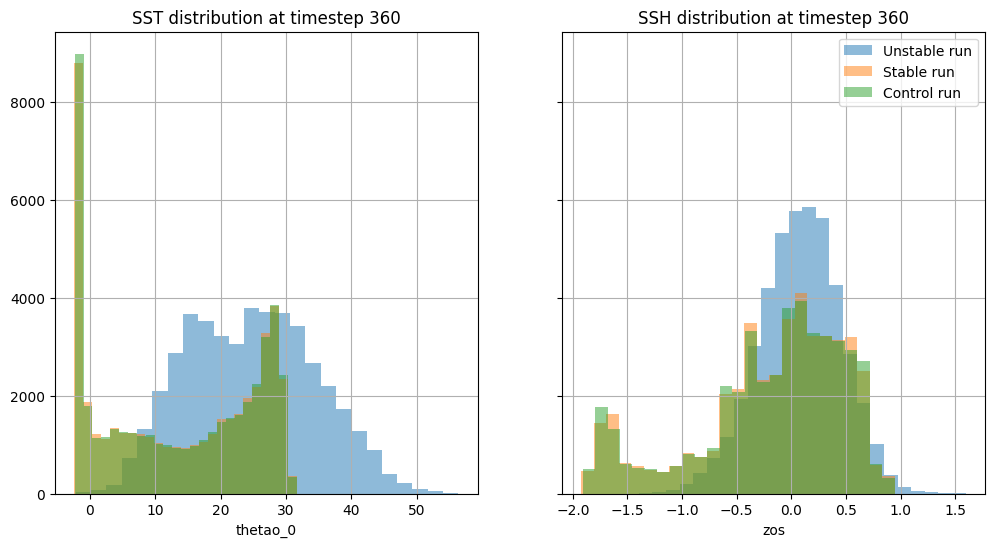

In [35]:
fig, (ax_sst, ax_ssh) = plt.subplots(1, 2, sharey=True, figsize=(12,6))

n_bins = 25
timestep = 360

stable_lbl = "Stable run"
unstable_lbl = "Unstable run"
control_lbl = "Control run"
alpha = 0.5

xr.plot.hist(unstable_rollout_ds.thetao_0.isel(time=timestep), bins=n_bins, ax=ax_sst, label=unstable_lbl, alpha=alpha);
xr.plot.hist(stable_rollout_ds.thetao_0.isel(time=timestep), bins=n_bins, ax=ax_sst, label=stable_lbl, alpha=alpha);

xr.plot.hist(unstable_rollout_ds.zos.isel(time=timestep), bins=n_bins, ax=ax_ssh, label=unstable_lbl, alpha=alpha);
xr.plot.hist(stable_rollout_ds.zos.isel(time=timestep), bins=n_bins, ax=ax_ssh, label=stable_lbl, alpha=alpha);

# Control run plots
xr.plot.hist(control_rollout_ds.thetao_0.isel(time=timestep), bins=n_bins, ax=ax_sst, label=control_lbl, alpha=alpha);
xr.plot.hist(control_rollout_ds.zos.isel(time=timestep), bins=n_bins, ax=ax_ssh, label=control_lbl, alpha=alpha);

ax_sst.set_title(f"SST distribution at timestep {timestep}")
ax_sst.grid()

ax_ssh.set_title(f"SSH distribution at timestep {timestep}")
ax_ssh.grid()
ax_ssh.legend()